In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayeshasiddiqa123/cars-pre")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cars-pre' dataset.
Path to dataset files: /kaggle/input/cars-pre


In [7]:
import pandas as pd
import numpy as np
df = pd.read_csv('/kaggle/input/cars-pre/car_price_prediction_.csv')

In [8]:
df

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Audi,2020,2.4,Petrol,Automatic,22650,Like New,61384.10,Q5
2496,2497,Audi,2001,5.7,Hybrid,Manual,77701,Like New,24710.35,A3
2497,2498,Ford,2021,1.1,Hybrid,Manual,272827,Like New,29902.45,Fiesta
2498,2499,Audi,2002,4.5,Diesel,Manual,229164,Like New,46085.67,Q5


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [10]:
X = df.drop(['Car ID' , 'Price' ] , axis = 1)
y = df['Price']

In [11]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
for column in X.columns:
    if X[column].dtype == 'object':
        X[column] = label.fit_transform(X[column])

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y.values.reshape(-1, 1))

In [13]:
import torch
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

class ANN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_features, 6),
            nn.Linear(6,2),
            nn.Linear(2,1)
        )
    def forward(self, x):
        return self.net(x)

In [15]:
shape = X.shape[1]
model = ANN(shape)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.5)
num_epochs = 100
result = []
for ep in range(num_epochs):
    # model training
    model.train()
    # forward pass
    y_preds = model(X_tensor)
    # loss calculation
    loss = criterion(y_preds, Y_tensor)
    # optimizer
    optimizer.zero_grad()
    # backward propagation
    loss.backward()
    # optimizer evaluation and weight update
    optimizer.step()
    model.eval()
    result.append(loss.item())
    # printing loss in each epoch
    print(f"Epoch {ep+1}/{num_epochs} | MSE: {loss.item():.6f}")

Epoch 1/100 | MSE: 1.757807
Epoch 2/100 | MSE: 1.248591
Epoch 3/100 | MSE: 1.059444
Epoch 4/100 | MSE: 1.001410
Epoch 5/100 | MSE: 1.000399
Epoch 6/100 | MSE: 1.000181
Epoch 7/100 | MSE: 1.000028
Epoch 8/100 | MSE: 0.999911
Epoch 9/100 | MSE: 0.999820
Epoch 10/100 | MSE: 0.999747
Epoch 11/100 | MSE: 0.999688
Epoch 12/100 | MSE: 0.999638
Epoch 13/100 | MSE: 0.999596
Epoch 14/100 | MSE: 0.999559
Epoch 15/100 | MSE: 0.999526
Epoch 16/100 | MSE: 0.999496
Epoch 17/100 | MSE: 0.999468
Epoch 18/100 | MSE: 0.999442
Epoch 19/100 | MSE: 0.999416
Epoch 20/100 | MSE: 0.999391
Epoch 21/100 | MSE: 0.999366
Epoch 22/100 | MSE: 0.999342
Epoch 23/100 | MSE: 0.999318
Epoch 24/100 | MSE: 0.999293
Epoch 25/100 | MSE: 0.999269
Epoch 26/100 | MSE: 0.999244
Epoch 27/100 | MSE: 0.999220
Epoch 28/100 | MSE: 0.999195
Epoch 29/100 | MSE: 0.999169
Epoch 30/100 | MSE: 0.999144
Epoch 31/100 | MSE: 0.999118
Epoch 32/100 | MSE: 0.999091
Epoch 33/100 | MSE: 0.999065
Epoch 34/100 | MSE: 0.999038
Epoch 35/100 | MSE: 0.9

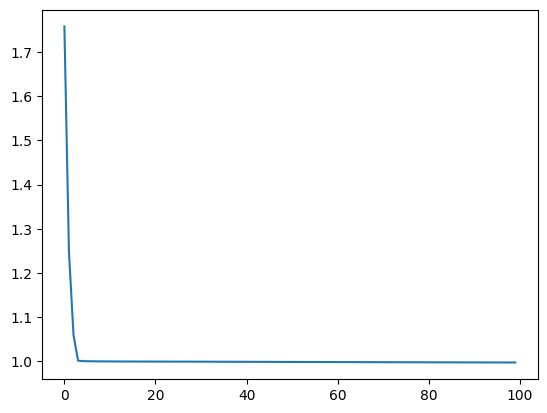

In [16]:
import matplotlib.pyplot as plt
plt.plot(result)

In [17]:
model.eval()

ANN(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=6, bias=True)
    (1): Linear(in_features=6, out_features=2, bias=True)
    (2): Linear(in_features=2, out_features=1, bias=True)
  )
)